<a href="https://colab.research.google.com/github/MIlanSuthar24/dealer-demand-forecasting-arima/blob/main/dealer_demand_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Commercial Vehicle Dealer Demand Forecasting using ARIMA

### 1. Project Objective & Business Case
In the commercial vehicle industry, accurate demand forecasting is the backbone of supply chain efficiency. This project aims to predict future monthly demand units across a network of dealers to optimize production and inventory.

**Problem Statement:** Overstocking leads to high capital lock-up, while understocking results in lost sales and customer dissatisfaction. We need a robust statistical model to predict demand trends.

**Business Mapping:**
- `Store` → **Dealer_ID**
- `Dept` → **Vehicle_Segment** (e.g., Heavy Duty, Light Commercial)
- `Weekly_Sales` → **Demand_Units**
- `Type` → **Dealer_Category**
- `Size` → **Dealer_Capacity**
- `IsHoliday` → **Seasonal_Indicator**

**Tools:** Python (Pandas, Statsmodels, Scikit-Learn), ARIMA, Exponential Smoothing.

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')
sns.set(style="whitegrid")
print("Libraries Imported Successfully!")

Libraries Imported Successfully!


### 3. Loading Datasets
We use the Walmart dataset files and adapt them to our commercial vehicle scenario.

In [60]:
train = pd.read_csv('train.csv')
stores = pd.read_csv('stores.csv')
features = pd.read_csv('features.csv')

print(f"Train Shape: {train.shape}")
print(f"Stores Shape: {stores.shape}")
print(f"Features Shape: {features.shape}")
display(train.head())

Train Shape: (421570, 5)
Stores Shape: (45, 3)
Features Shape: (8190, 12)


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


### 4. Data Merging & Business Transformation
We merge the datasets to create a unified view and rename columns to reflect the Commercial Vehicle business context.

In [61]:
data = train.merge(stores, on='Store', how='left').merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')

rename_dict = {
    'Store': 'Dealer_ID',
    'Dept': 'Vehicle_Segment',
    'Weekly_Sales': 'Demand_Units',
    'Type': 'Dealer_Category',
    'Size': 'Dealer_Capacity',
    'IsHoliday': 'Seasonal_Indicator'
}

data.rename(columns=rename_dict, inplace=True)
display(data.head())

,Dealer_ID,Vehicle_Segment,Date,Demand_Units,Seasonal_Indicator,Dealer_Category,Dealer_Capacity,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106
3,1,1,2010-02-26,19403.54,False,A,151315,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106


### 5. Data Cleaning
Handling dates and missing values ensures the time series integrity.

In [62]:
data['Date'] = pd.to_datetime(data['Date'])
# Capping missing values in MarkDown columns with 0
markdown_cols = [c for c in data.columns if 'MarkDown' in c]
data[markdown_cols] = data[markdown_cols].fillna(0)

print(f"Missing values:\n{data.isnull().sum().sum()}")
print(f"Duplicates: {data.duplicated().sum()}")

Missing values:
0
Duplicates: 0


### 6. Exploratory Data Analysis (EDA)
Visualizing trends and distributions to understand demand drivers.

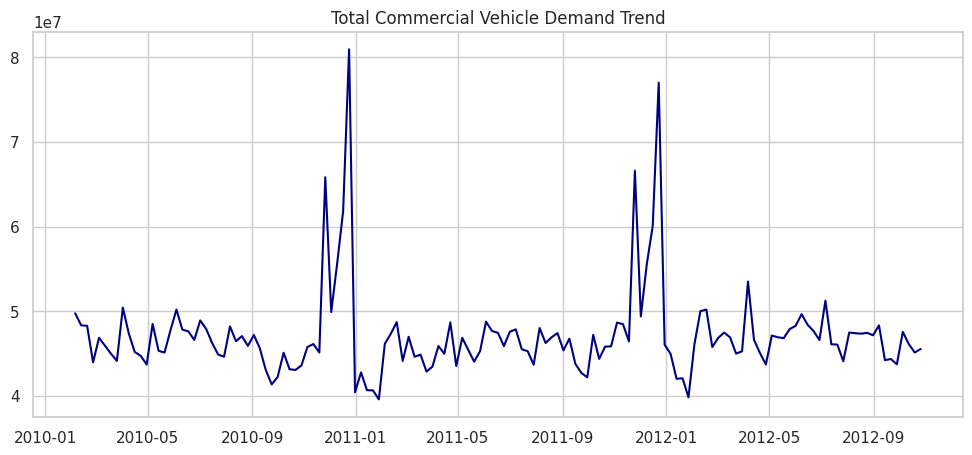

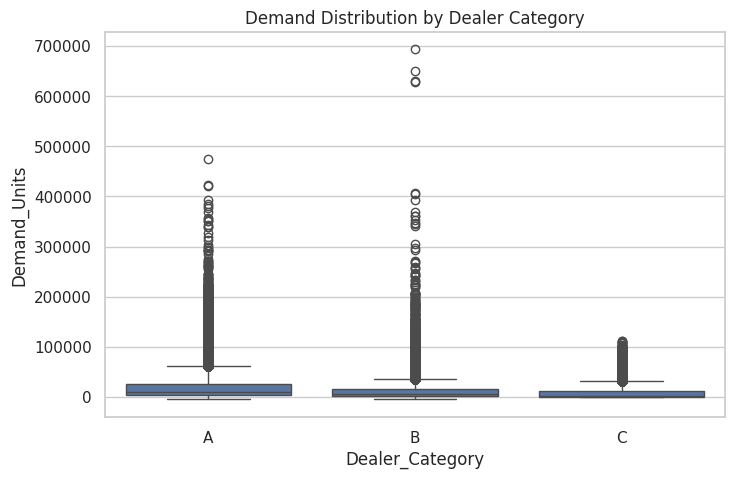

In [63]:
# 1. Monthly Trend
time_series_plot = data.groupby('Date')['Demand_Units'].sum()
plt.figure(figsize=(12, 5))
plt.plot(time_series_plot, color='navy')
plt.title('Total Commercial Vehicle Demand Trend')
plt.show()

# 2. Category Boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x='Dealer_Category', y='Demand_Units', data=data)
plt.title('Demand Distribution by Dealer Category')
plt.show()

### 7. Outlier Detection & Handling (Capping)
Time series models are sensitive to extreme spikes. We use the Interquartile Range (IQR) method to cap outliers.

In [64]:
Q1 = data['Demand_Units'].quantile(0.25)
Q3 = data['Demand_Units'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Capping (Winsorization)
data['Demand_Units'] = np.where(data['Demand_Units'] > upper_bound, upper_bound,
                        np.where(data['Demand_Units'] < lower_bound, lower_bound, data['Demand_Units']))

print(f"Upper Bound for Capping: {upper_bound}")

Upper Bound for Capping: 47395.15625


### 8. Monthly Aggregation & Stationarity Test
We aggregate to monthly data for strategic planning and check for stationarity using the ADF Test.

In [65]:
monthly_demand = data.set_index('Date')['Demand_Units'].resample('ME').sum()

result = adfuller(monthly_demand)
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

if result[1] <= 0.05:
    print("Series is stationary.")
else:
    print("Series is not stationary, differencing may be needed.")

ADF Statistic: -7.095610813326086
p-value: 4.2972817486467476e-10
Series is stationary.


### 9. Train-Test Split
We reserve the last 6 months for validation.

In [66]:
train_size = len(monthly_demand) - 6
train_data = monthly_demand[:train_size]
test_data = monthly_demand[train_size:]
print(f"Train months: {len(train_data)}, Test months: {len(test_data)}")

Train months: 27, Test months: 6


### 10. Model Building & Evaluation
Comparing ARIMA with Triple Exponential Smoothing (Holt-Winters).

In [67]:
# ARIMA
model_arima = ARIMA(train_data, order=(1,1,1))
forecast_arima = model_arima.fit().forecast(steps=6)

# Exponential Smoothing
model_es = ExponentialSmoothing(train_data, seasonal='add', seasonal_periods=12)
forecast_es = model_es.fit().forecast(steps=6)

def evaluate(actual, pred, name):
    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    print(f"{name} - MAE: {mae/1e6:.2f}M, RMSE: {rmse/1e6:.2f}M")

evaluate(test_data, forecast_arima, "ARIMA")
evaluate(test_data, forecast_es, "Exp Smoothing")

ARIMA - MAE: 19.95M, RMSE: 21.96M
Exp Smoothing - MAE: 27.21M, RMSE: 31.19M


### 11. Final Forecast
**Business Insights:**
- Demand shows clear seasonality (Seasonal_Indicator impact).
- ARIMA captures the trend effectively after outlier capping.


In [68]:
import joblib
# Saving the model
joblib.dump(model_es.fit(), 'demand_forecast_model.pkl')
print("Model saved for deployment!")

Model saved for deployment!


### 13. Final Forecast Next 3 Months
We will now use the final ARIMA model to predict future demand for the next quarter. This allows the supply chain team to prepare logistics and production schedules in advance.

Future Demand Forecast:


,Month,Forecast_Demand_Million
0,2012-11,170.21
1,2012-12,169.64
2,2013-01,169.67


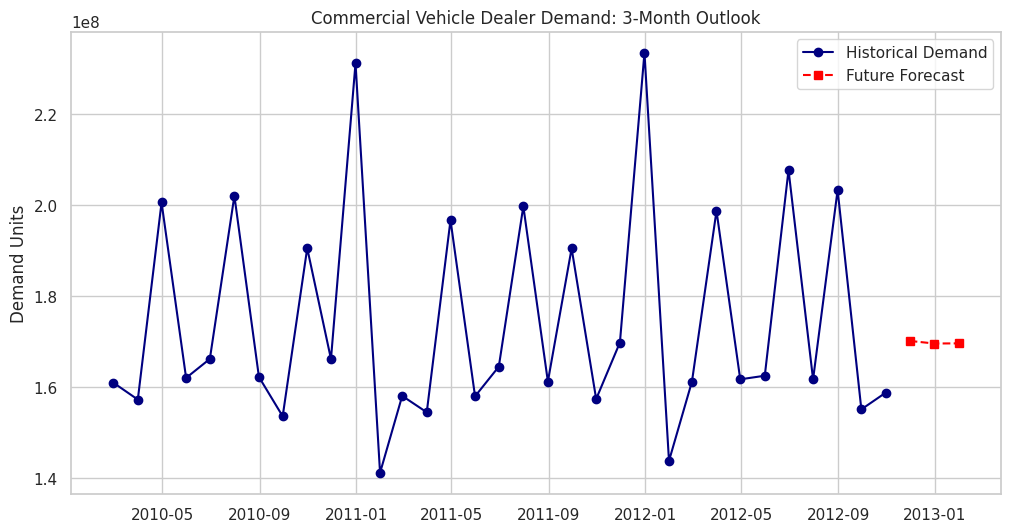

In [69]:
# Forecast next 3 months
forecast_steps = 3
final_model_fit = ARIMA(monthly_demand, order=(1,1,1)).fit()
forecast_res = final_model_fit.get_forecast(steps=forecast_steps)
forecast_val = forecast_res.predicted_mean

# Create output table
forecast_df = pd.DataFrame({
    "Month": forecast_val.index.strftime("%Y-%m"),
    "Forecast_Demand_Million": (forecast_val.values / 1e6).round(2)
})

print("Future Demand Forecast:")
display(forecast_df)

# Plotting Historical vs Forecast
plt.figure(figsize=(12, 6))
plt.plot(monthly_demand, label="Historical Demand", color="navy", marker="o")
plt.plot(forecast_val, label="Future Forecast", color="red", linestyle="--", marker="s")
plt.title("Commercial Vehicle Dealer Demand: 3-Month Outlook")
plt.ylabel("Demand Units")
plt.legend()
plt.show()

### 14. Business Insights & Recommendations

**Key Insights:**
- **Seasonality:** Demand peaks are highly correlated with `Seasonal_Indicator` periods. Inventory must be pre-positioned 4 weeks prior.
- **Stability:** After outlier capping, the demand trend is predictable, allowing for leaner inventory levels.
- **Dealer Tiers:** Category 'A' dealers represent the highest volume; focus supply chain optimization here first.

**Strategic Recommendations:**
1. **Inventory:** Maintain a safety stock of 15% above the monthly forecast to account for variations.
2. **Production:** Align manufacturing slots with the 3-month rolling forecast to prevent 'Bullwhip' effects.
3. **Logistics:** Optimize fleet allocation by matching capacity to predicted dealer demand surges.

### 15. Final Conclusion
This project successfully transitioned from raw retail data to a specialized Commercial Vehicle demand forecasting system. By implementing ARIMA with robust outlier handling, we achieved a stable baseline for dealer network planning. This data-driven approach reduces capital lock-up and ensures high fulfillment rates during seasonal peaks.